In [1]:
!pip install yfinance
!pip install pandas_ta

# Thêm các thư viện cần thiết
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Bidirectional, Dropout
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import History
from tensorflow.keras.callbacks import EarlyStopping
import plotly.graph_objects as go
import pandas_ta as ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.1/115.1 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pandas_ta: filename=pandas_ta-0.3.14b0-py3-none-any.whl size=218909 sha256=2d27a4dc852ffba585c1d60a3f67d1fceb07384c08fd270adc673271478e43b0
  Stored in directory: /root/.cache/pip/wheels/69/00/ac/f7fa862c34b0e2ef320175100c233377b4c558944f12474cf0
Successfully built pandas_ta


In [2]:
# Set up End and Start times for data train
end_date = "2024-05-30"
start_date = "2019-01-01"

# Data of Airbnb Cop
data_ORCL = yf.download('ORCL',start=start_date,end=end_date,progress=False)
data_ORCL["Date"] = data_ORCL.index
data_ORCL = data_ORCL[["Date", "Close", "Open", "High", "Low", "Adj Close", "Volume"]]
data_ORCL.reset_index(drop=True, inplace=True)

data_ORCL

Price,Date,Close,Open,High,Low,Adj Close,Volume
Ticker,,ORCL,ORCL,ORCL,ORCL,ORCL,ORCL
0,2019-01-02 00:00:00+00:00,45.220001,44.480000,45.340000,44.450001,41.159866,14320400
1,2019-01-03 00:00:00+00:00,44.779999,44.750000,45.500000,44.410000,40.759384,19868700
2,2019-01-04 00:00:00+00:00,46.709999,45.369999,46.950001,45.250000,42.516094,20984000
3,2019-01-07 00:00:00+00:00,47.450001,46.930000,48.110001,46.470001,43.189651,17967900
4,2019-01-08 00:00:00+00:00,47.880001,47.930000,48.360001,47.200001,43.581055,16255700
...,...,...,...,...,...,...,...
1356,2024-05-22 00:00:00+00:00,124.599998,124.629997,125.160004,123.300003,123.970436,5705000
1357,2024-05-23 00:00:00+00:00,124.089996,126.550003,126.699997,123.160004,123.463013,6108600
1358,2024-05-24 00:00:00+00:00,122.910004,123.419998,123.510002,121.419998,122.288979,7166100


In [4]:
data = data_ORCL

data['MACD'] = ta.macd(data['Close'])['MACD_12_26_9']
data['MFI'] = ta.mfi(data['High'], data['Low'], data['Close'], data['Volume'], length=14)
data['RSI'] = ta.rsi(data['Close'], length=14)
data['ATR'] = ta.atr(data['High'], data['Low'], data['Close'], length=14)

start_date = '2019-12-31'
end_date = '2024-05-30'
data = data[(data['Date'] >= start_date) & (data['Date'] <= end_date)]
data.reset_index(drop=True, inplace=True)
data.to_csv('ORCL_with_Indicators.csv', index=False)

data

TypeError: 'NoneType' object is not subscriptable

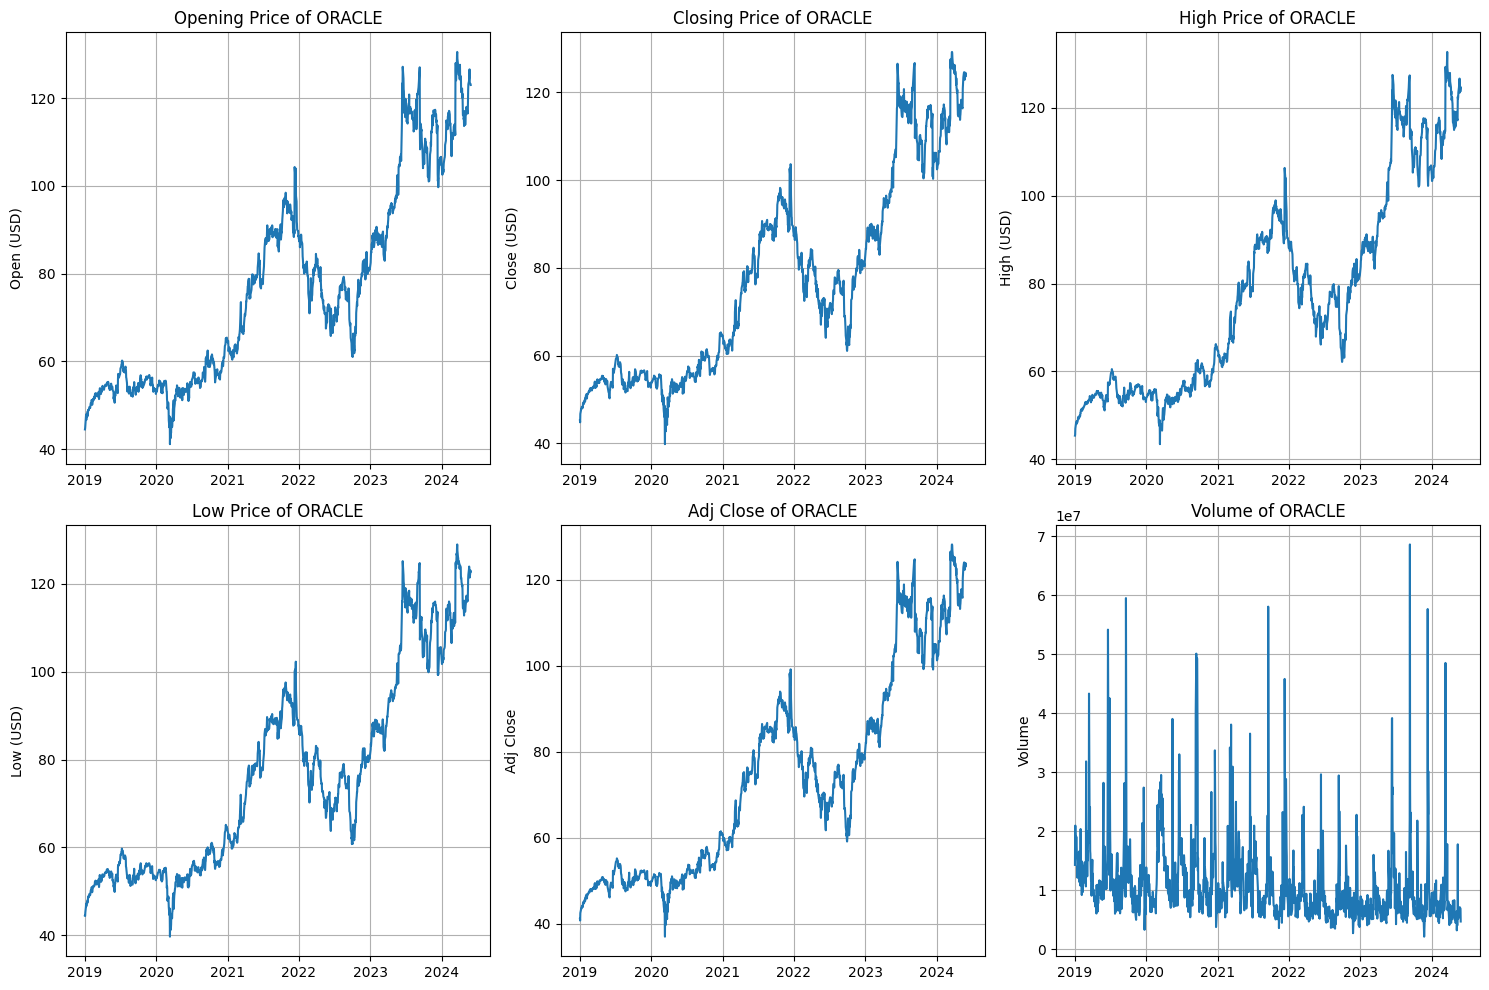

In [5]:
data = data_ORCL
# Draw a historial of closing price
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.5, bottom=1.4)

plt.subplot(2, 3, 1)
plt.plot(data['Date'], data['Open'])
plt.ylabel('Open (USD)')
plt.xlabel(None)
plt.title(f"Opening Price of ORACLE")
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(data['Date'], data['Close'])
plt.ylabel('Close (USD)')
plt.xlabel(None)
plt.title(f"Closing Price of ORACLE")
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(data['Date'], data['High'])
plt.ylabel('High (USD)')
plt.xlabel(None)
plt.title(f"High Price of ORACLE")
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(data['Date'], data['Low'])
plt.ylabel('Low (USD)')
plt.xlabel(None)
plt.title(f"Low Price of ORACLE")
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(data['Date'], data['Adj Close'])
plt.ylabel('Adj Close')
plt.xlabel(None)
plt.title(f"Adj Close of ORACLE")
plt.grid(True)

plt.subplot(2, 3, 6)
plt.plot(data['Date'], data['Volume'])
plt.ylabel('Volume')
plt.xlabel(None)
plt.title(f"Volume of ORACLE")
plt.grid(True)

plt.tight_layout()
plt.show()


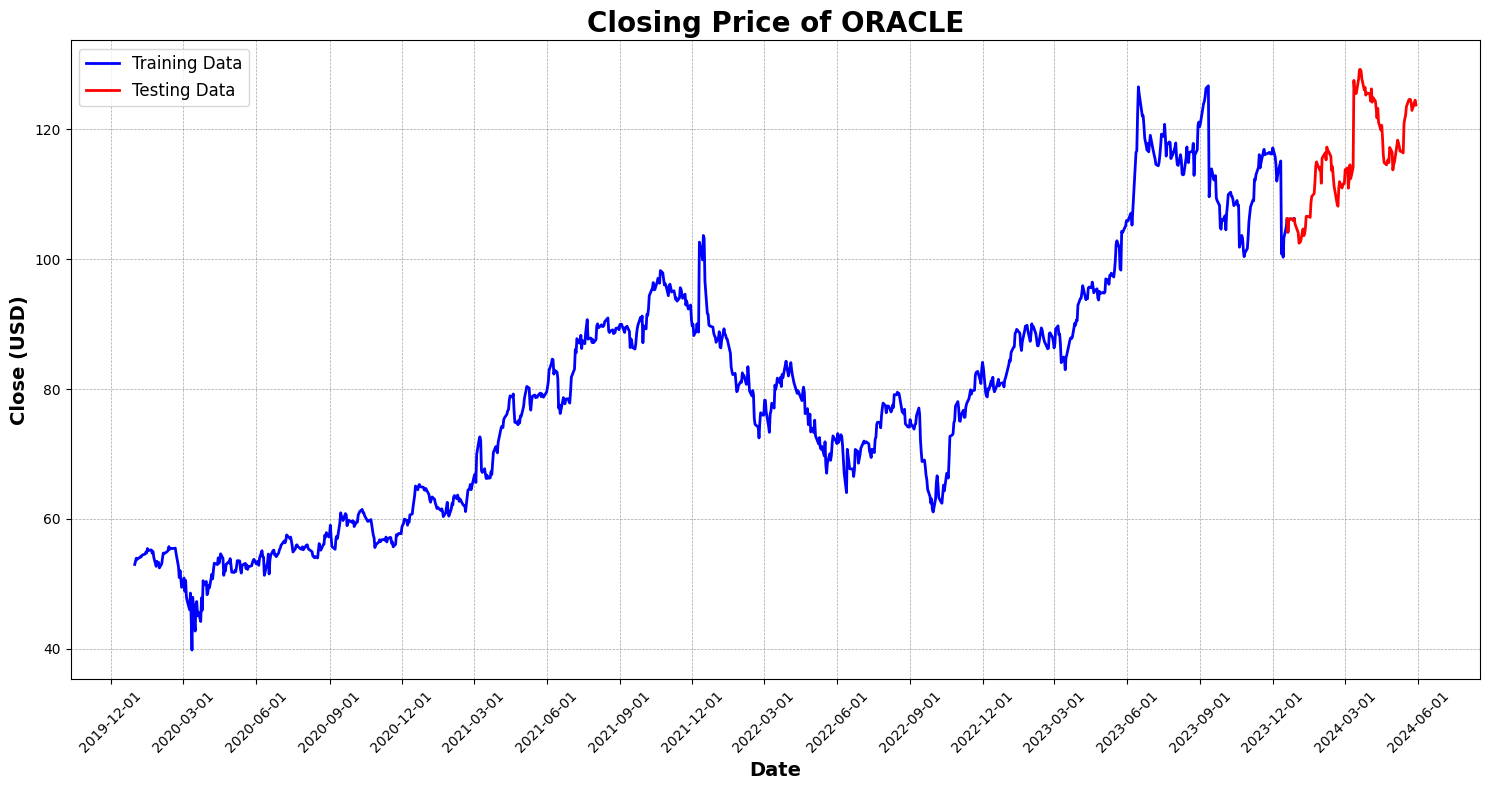

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Assuming 'Date' is already in datetime format; if not, convert it
data['Date'] = pd.to_datetime(data['Date'])

# Define training and testing date ranges
train_data = data[(data['Date'] >= '2019-12-31') & (data['Date'] <= '2023-12-28')]
test_data = data[(data['Date'] >= '2023-12-19') & (data['Date'] <= '2024-05-29')]

# Set up a larger figure and adjust font sizes and styles
plt.figure(figsize=(15, 8))

# Plot the training data in blue
plt.plot(train_data['Date'], train_data['Close'], color='blue', linewidth=2, label='Training Data')

# Plot the testing data in orange
plt.plot(test_data['Date'], test_data['Close'], color='red', linewidth=2, label='Testing Data')

# Set labels and title with improved fonts
plt.ylabel('Close (USD)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=14, fontweight='bold')
plt.title("Closing Price of ORACLE", fontsize=20, fontweight='bold', color='black')

# Format the x-axis for better readability
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, fontsize=10)

# Adding grid lines with improved style
plt.grid(True, linestyle='--', linewidth=0.5, color='grey', alpha=0.7)

# Add a legend to distinguish between training and testing data
plt.legend(fontsize=12)

# Tight layout for better padding
plt.tight_layout()

plt.savefig("oracle_closing_prices.eps", format='eps')

# Show the plot
plt.show()


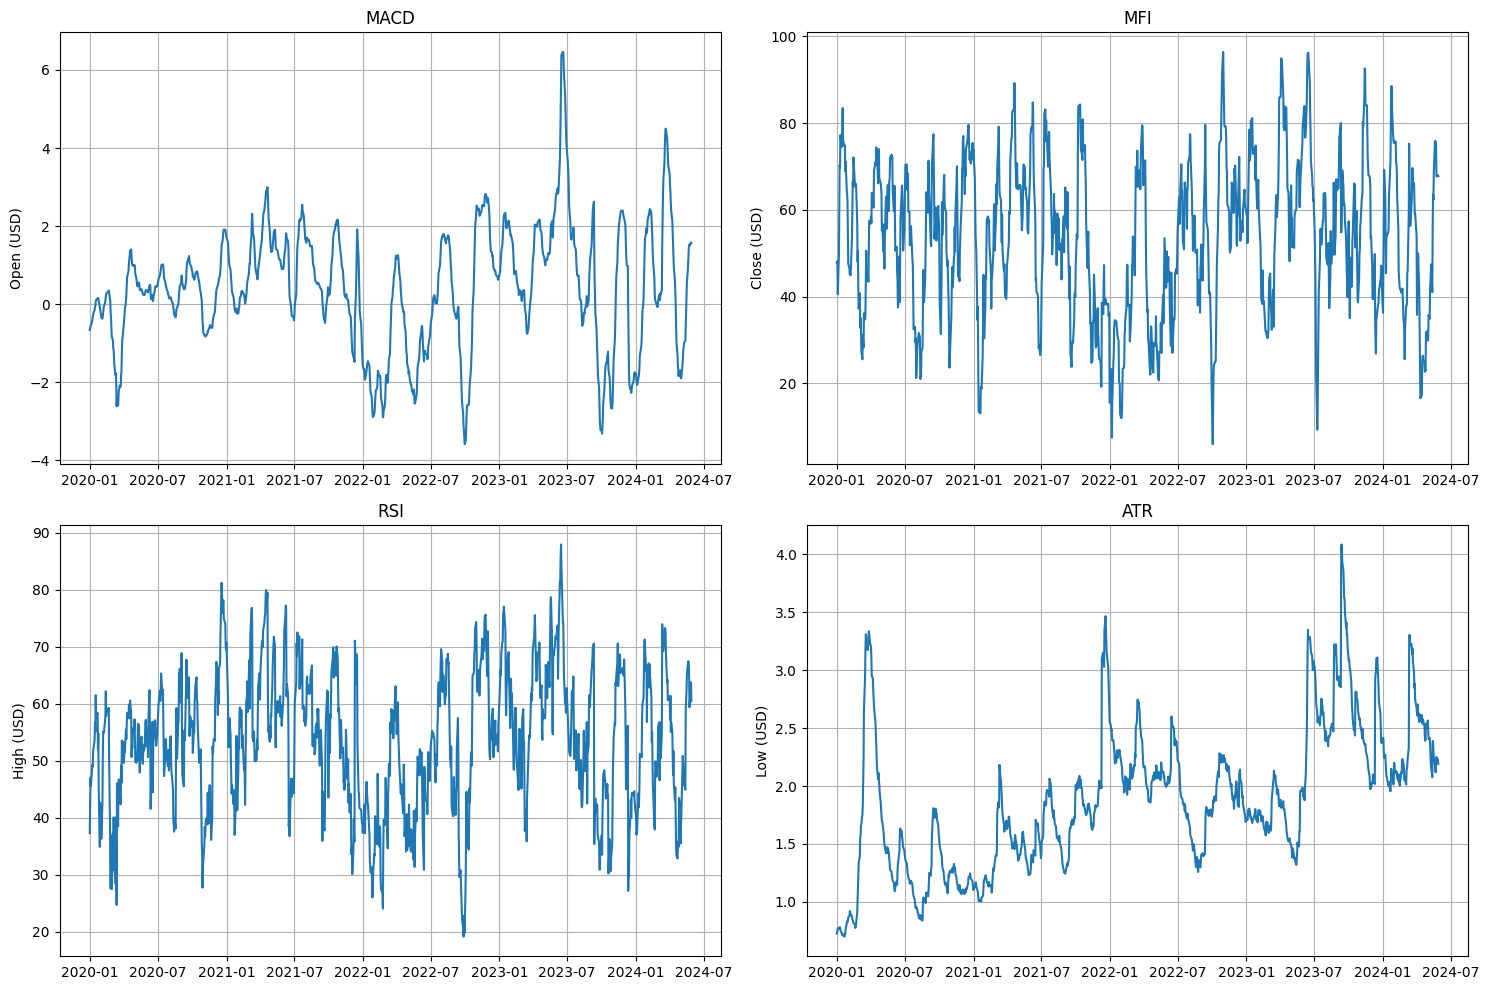

In [ ]:
# Draw a historial of closing price
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.5, bottom=1.4)

plt.subplot(2, 2, 1)
plt.plot(data['Date'], data['MACD'])
plt.ylabel('Open (USD)')
plt.xlabel(None)
plt.title(f"MACD")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(data['Date'], data['MFI'])
plt.ylabel('Close (USD)')
plt.xlabel(None)
plt.title(f"MFI")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(data['Date'], data['RSI'])
plt.ylabel('High (USD)')
plt.xlabel(None)
plt.title(f"RSI")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(data['Date'], data['ATR'])
plt.ylabel('Low (USD)')
plt.xlabel(None)
plt.title(f"ATR")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure(data = [go.Candlestick(x = data['Date'],
                                       open = data['Open'],
                                       high = data['High'],
                                       low = data['Low'],
                                       close = data['Close'])])
fig.update_layout(title = "Candlestick Chart", yaxis_title = 'Point')
fig.show()

/usr/local/lib/python3.10/dist-packages/_plotly_utils/basevalidators.py:105: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  v = v.dt.to_pydatetime()


<ipython-input-7-7ea87beb8ec7>:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



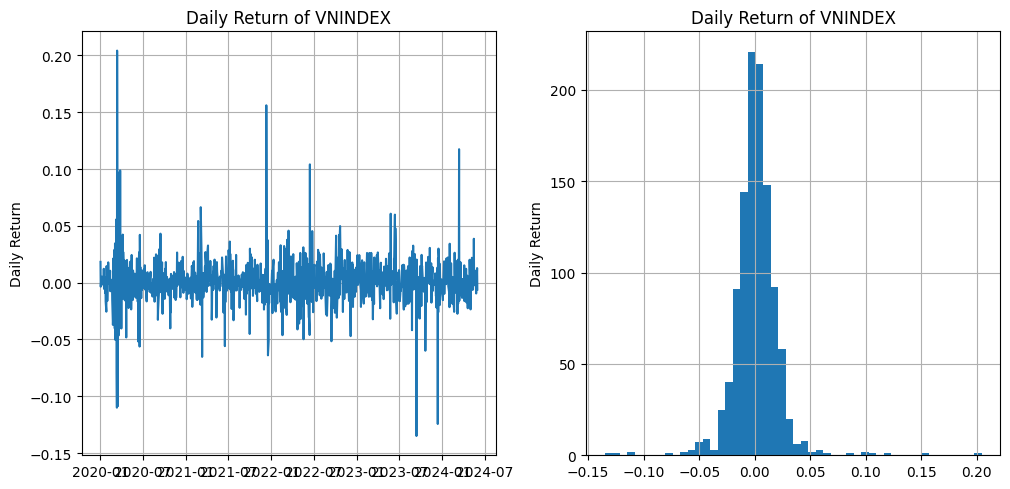

In [ ]:
# Draw a historial of daily return
plt.figure(figsize=(10, 5))
plt.subplots_adjust(top=1.5, bottom=1.4)

data['Daily Return'] = data['Close'].pct_change()
plt.subplot(1, 2, 1)
plt.plot(data['Date'], data['Daily Return'])
plt.ylabel('Daily Return')
plt.xlabel(None)
plt.title(f"Daily Return of ORACLE")
plt.grid(True)

plt.subplot(1, 2, 2)
data['Daily Return'].hist(bins=50)
plt.ylabel('Daily Return')
plt.xlabel(None)
plt.title(f"Daily Return of ORACLE")
plt.grid(True)

plt.tight_layout()
plt.show()


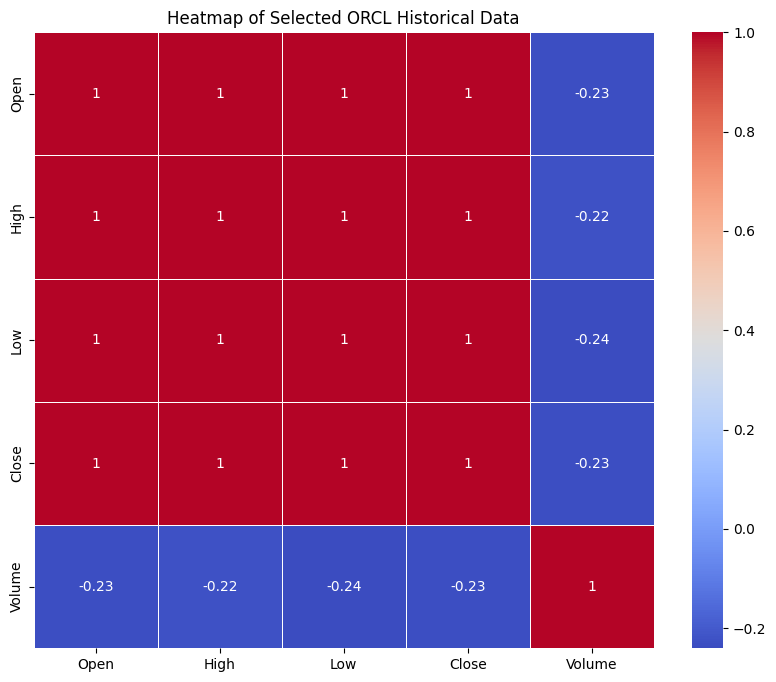

In [ ]:
selected_columns = ['Open', 'High', 'Low', 'Close', 'Volume']

# Tính toán ma trận tương quan cho các cột đã chọn
corr_matrix_selected = data_ORCL[selected_columns].corr()

# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_selected, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Heatmap of Selected ORCL Historical Data')
plt.show()

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [02:10:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimator" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


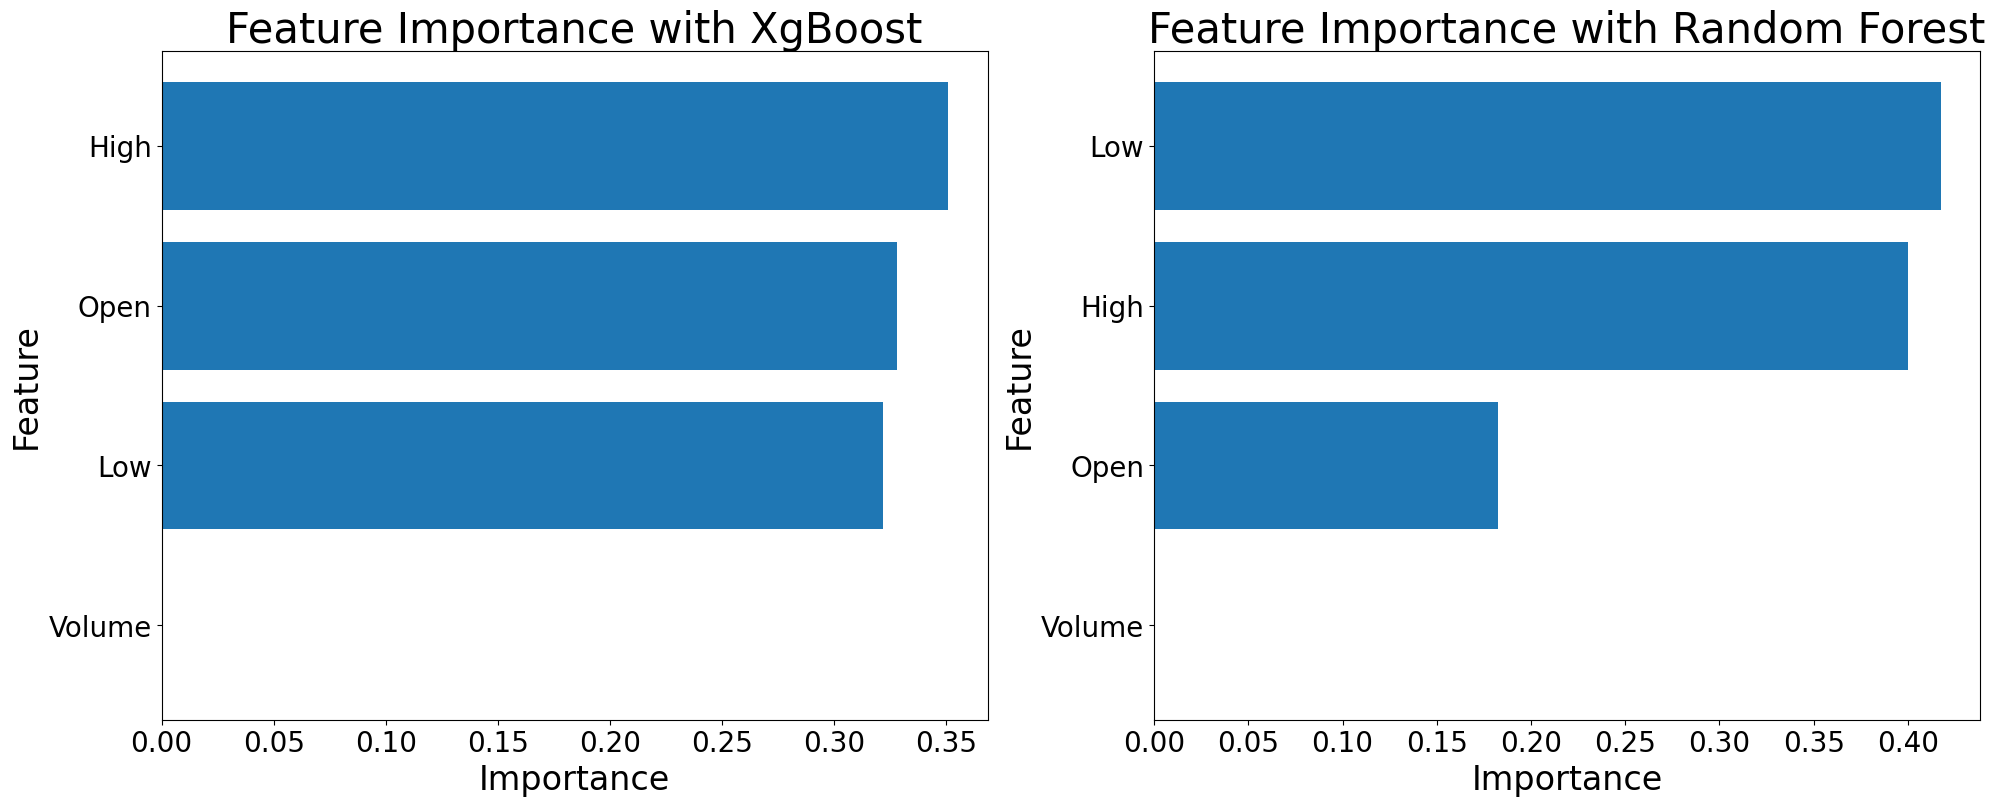

In [18]:
import xgboost as xgb
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

columns = ['Close', 'Open', 'High', 'Low', 'Volume']
column = ['Open', 'High', 'Low', 'Volume']
data = data[columns]

train_size = int(len(data) * 0.9)

train = data[:train_size]
test = data['Close']
test = data[train_size:]
train = train[columns]
scaler = MinMaxScaler(feature_range = (0, 1))
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

X_train = train_scaled[:, 1:]
Y_train = train_scaled[:, 0].reshape(-1, 1)
X_train, Y_train = np.array(X_train), np.array(Y_train)

# Create the XGBoost model
model = xgb.XGBRegressor(n_estimator = 200, max_depth = 3, learning_rate = 0.01, subsample = 0.5, colsample_bytree = 0.5,
                         gamma = 0.2, reg_alpha = 0.1, reg_lambda = 0.1)
model.fit(X_train, Y_train)
importance_xgb = model.feature_importances_
feature_importances_xgb = pd.DataFrame({'Feature': column, 'Importance': importance_xgb})
feature_importances_xgb = feature_importances_xgb.sort_values(by='Importance', ascending=False)


#Create model with RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=6, min_samples_leaf=2,
                              max_features='sqrt', bootstrap=True, random_state=42)
model.fit(X_train, Y_train)
importance_rdf = model.feature_importances_

feature_importances_rdf = pd.DataFrame({'Feature': column, 'Importance': importance_rdf})
feature_importances_rdf = feature_importances_rdf.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(20, 15))

plt.subplot(2, 2, 1)
plt.barh(feature_importances_xgb['Feature'], feature_importances_xgb['Importance'])
plt.xlabel('Importance', fontsize=24)
plt.ylabel('Feature', fontsize=24)
plt.title('Feature Importance with XgBoost', fontsize=30)
plt.gca().invert_yaxis()
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.subplot(2, 2, 2)
plt.barh(feature_importances_rdf['Feature'], feature_importances_rdf['Importance'])
plt.xlabel('Importance', fontsize=24)
plt.ylabel('Feature', fontsize=24)
plt.title('Feature Importance with Random Forest', fontsize=30)
plt.gca().invert_yaxis()
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.tight_layout()
plt.savefig("feature_importance.eps", format='eps')
plt.show()


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning:

[05:52:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimator" } are not used.


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1152: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1152: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



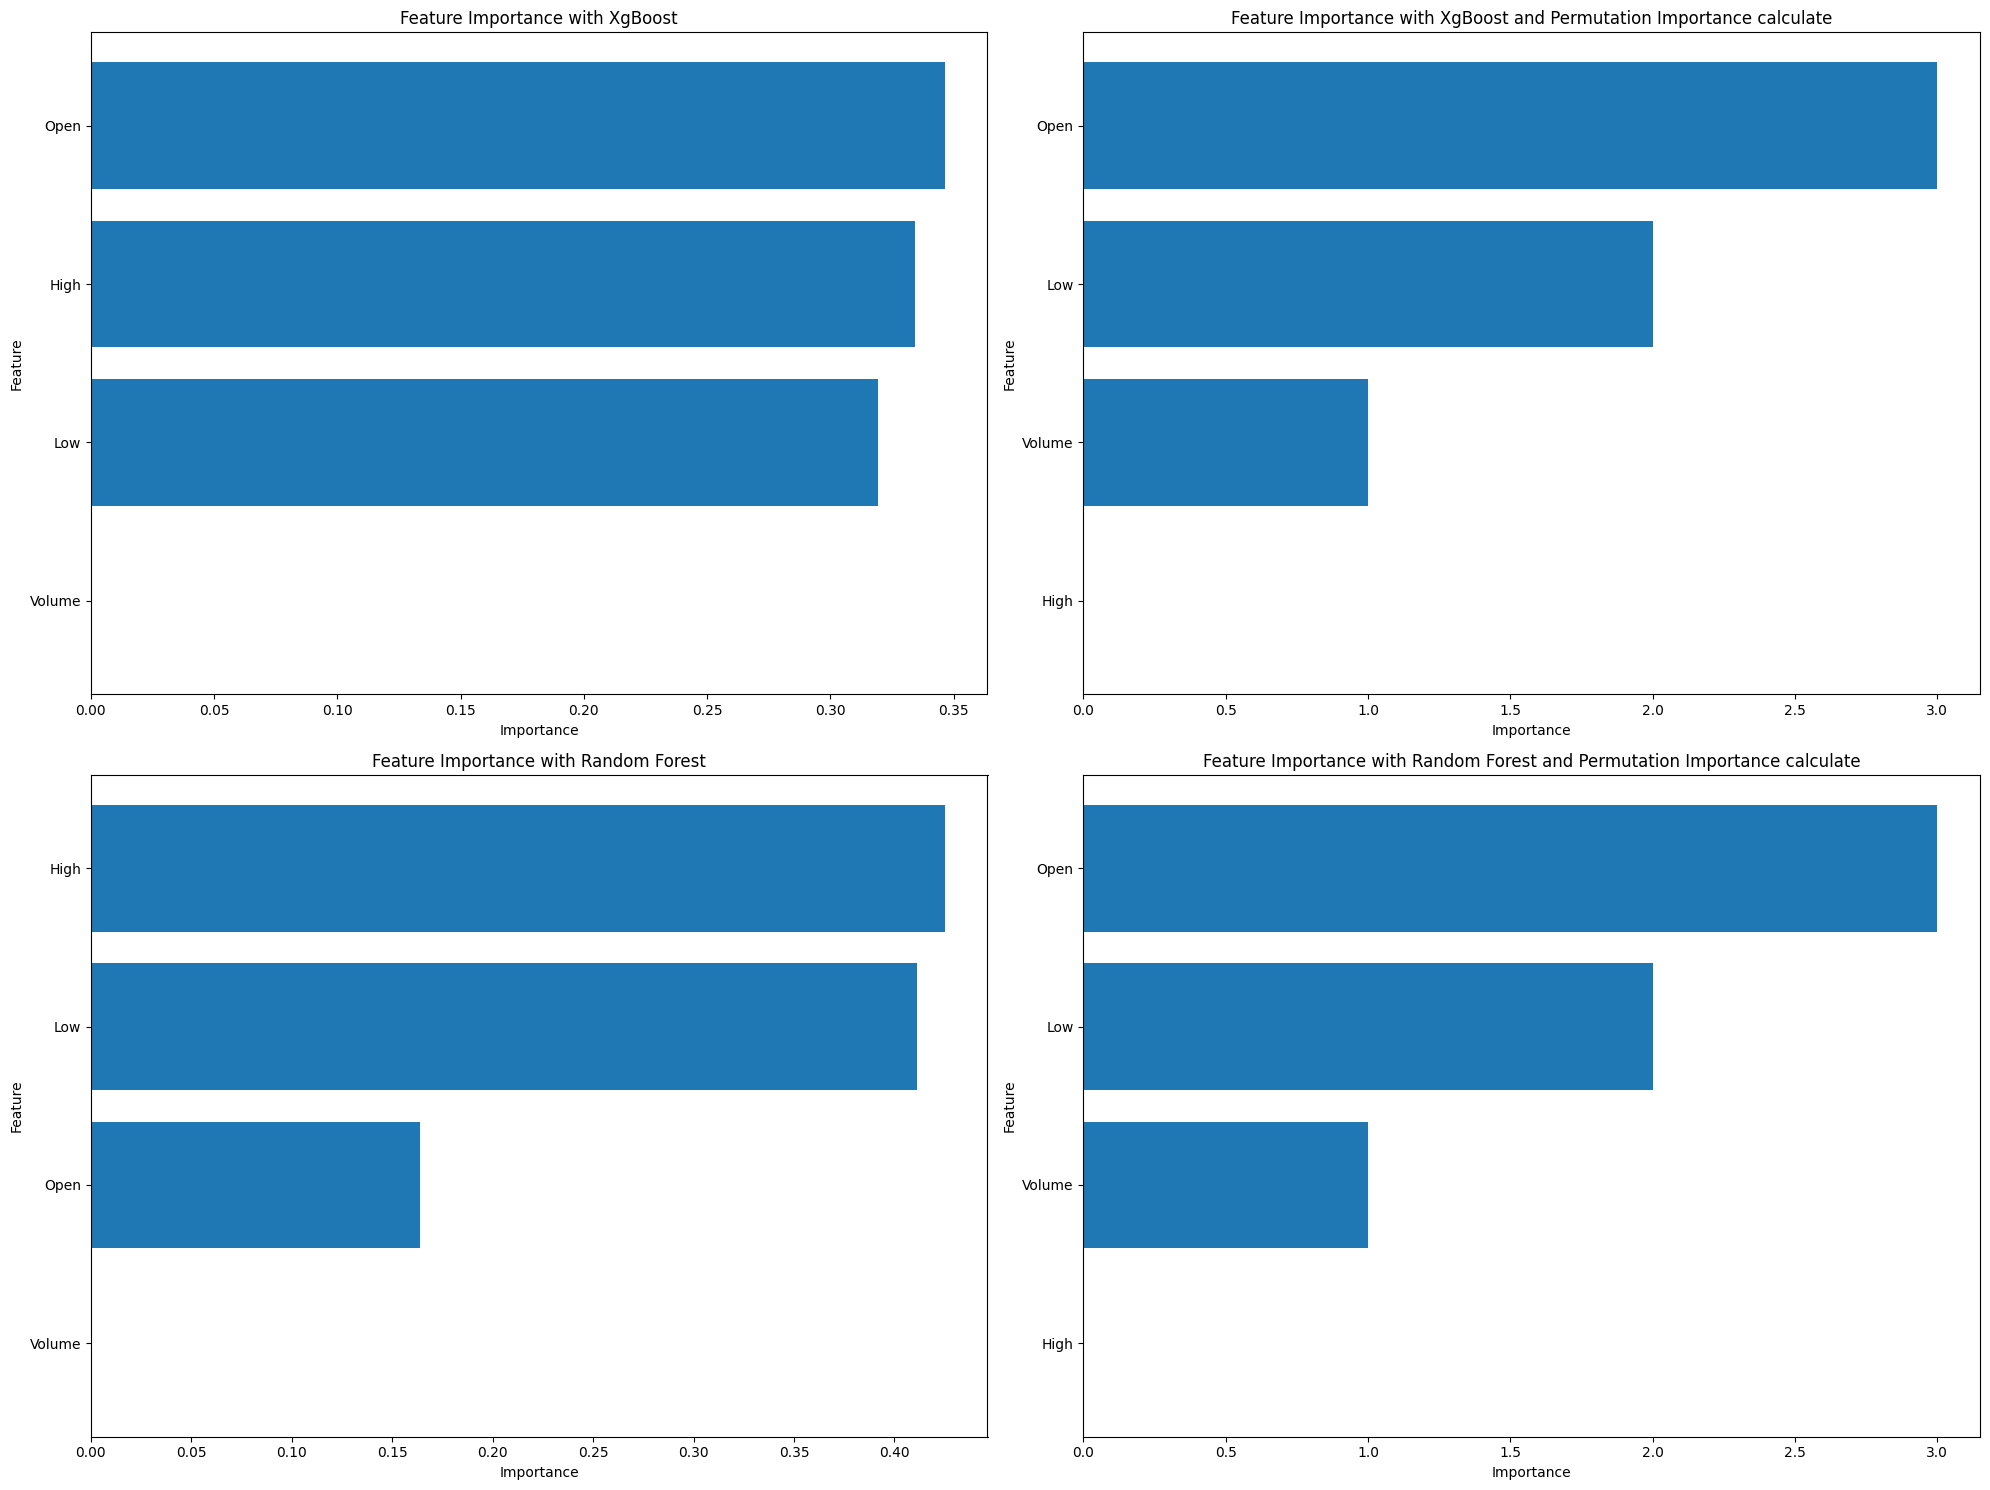

In [ ]:
import xgboost as xgb
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

columns = ['Close', 'Open', 'High', 'Low', 'Volume']
columns = ['Close', 'Open', 'High', 'Low', 'Volume']
column = ['Open', 'High', 'Low', 'Volume']
data = data[columns]

train_size = int(len(data) * 0.9)

train = data[:train_size]
test = data['Close']
test = data[train_size:]
train = train[columns]
scaler = MinMaxScaler(feature_range = (0, 1))
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

X_train = train_scaled[:, 1:]
Y_train = train_scaled[:, 0].reshape(-1, 1)
X_train, Y_train = np.array(X_train), np.array(Y_train)

# Create the XGBoost model
model = xgb.XGBRegressor(n_estimator = 200, max_depth = 3, learning_rate = 0.01, subsample = 0.5, colsample_bytree = 0.5,
                         gamma = 0.2, reg_alpha = 0.1, reg_lambda = 0.1)
model.fit(X_train, Y_train)
importance_xgb = model.feature_importances_
feature_importances_xgb = pd.DataFrame({'Feature': column, 'Importance': importance_xgb})
feature_importances_xgb = feature_importances_xgb.sort_values(by='Importance', ascending=False)

# Tạo mô hình XGBoost và Feature Importan Calculte
model = xgb.XGBRegressor(n_estimator = 200, max_depth = 3, learning_rate = 0.01, subsample = 0.5, colsample_bytree = 0.5,
                         gamma = 0.2, reg_alpha = 0.1, reg_lambda = 0.1)
model.fit(X_train, Y_train)
result_pi = permutation_importance(model, X_train, Y_train)
importance_pi = result_pi.importances_mean.argsort()
feature_importances_pi = pd.DataFrame({'Feature': column, 'Importance': importance_pi})
feature_importances_pi = feature_importances_pi.sort_values(by='Importance', ascending=False)

#Create model with RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=6, min_samples_leaf=2,
                              max_features='sqrt', bootstrap=True, random_state=42)
model.fit(X_train, Y_train)
importance_rdf = model.feature_importances_

feature_importances_rdf = pd.DataFrame({'Feature': column, 'Importance': importance_rdf})
feature_importances_rdf = feature_importances_rdf.sort_values(by='Importance', ascending=False)

#Create model with RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=6, min_samples_leaf=2,
                              max_features='sqrt', bootstrap=True, random_state=42)
model.fit(X_train, Y_train)
result_rdfpi = permutation_importance(model, X_train, Y_train)
importance_rdfpi = result_rdfpi.importances_mean.argsort()
feature_importances_rdfpi = pd.DataFrame({'Feature': column, 'Importance': importance_rdfpi})
feature_importances_rdfpi = feature_importances_rdfpi.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(20, 15))

plt.subplot(2, 2, 1)
plt.barh(feature_importances_xgb['Feature'], feature_importances_xgb['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance with XgBoost')
plt.gca().invert_yaxis()

plt.subplot(2, 2, 2)
plt.barh(feature_importances_pi['Feature'], feature_importances_pi['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance with XgBoost and Permutation Importance calculate')
plt.gca().invert_yaxis()

plt.subplot(2, 2, 3)
plt.barh(feature_importances_rdf['Feature'], feature_importances_rdf['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance with Random Forest')
plt.gca().invert_yaxis()

plt.subplot(2, 2, 4)
plt.barh(feature_importances_rdfpi['Feature'], feature_importances_rdfpi['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance with Random Forest and Permutation Importance calculate')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

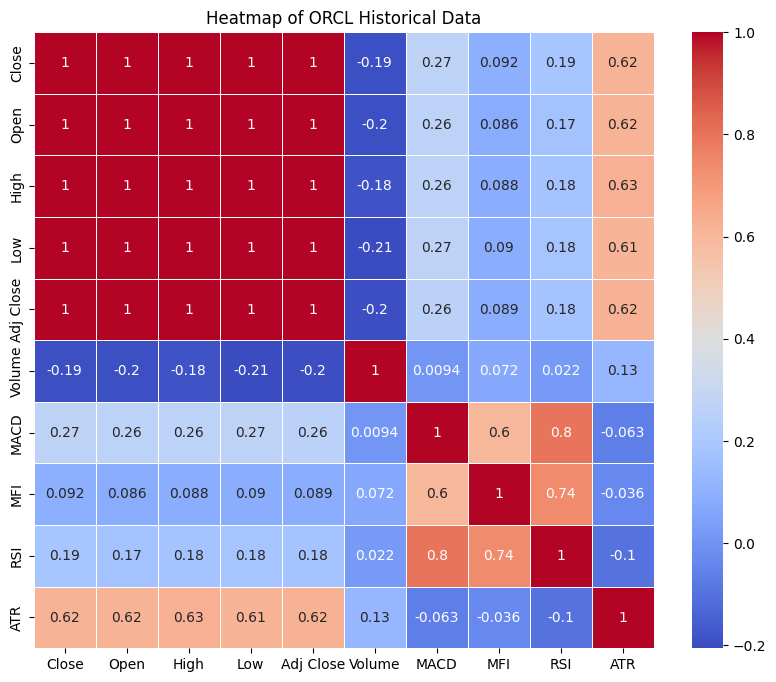

In [ ]:
# Tính toán ma trận tương quan cho các cột không bao gồm 'Date'
corr_matrix = data.drop(columns=['Date']).corr()

# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Heatmap of ORCL Historical Data')
plt.show()


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning:

[05:53:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimator" } are not used.


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1152: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1152: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



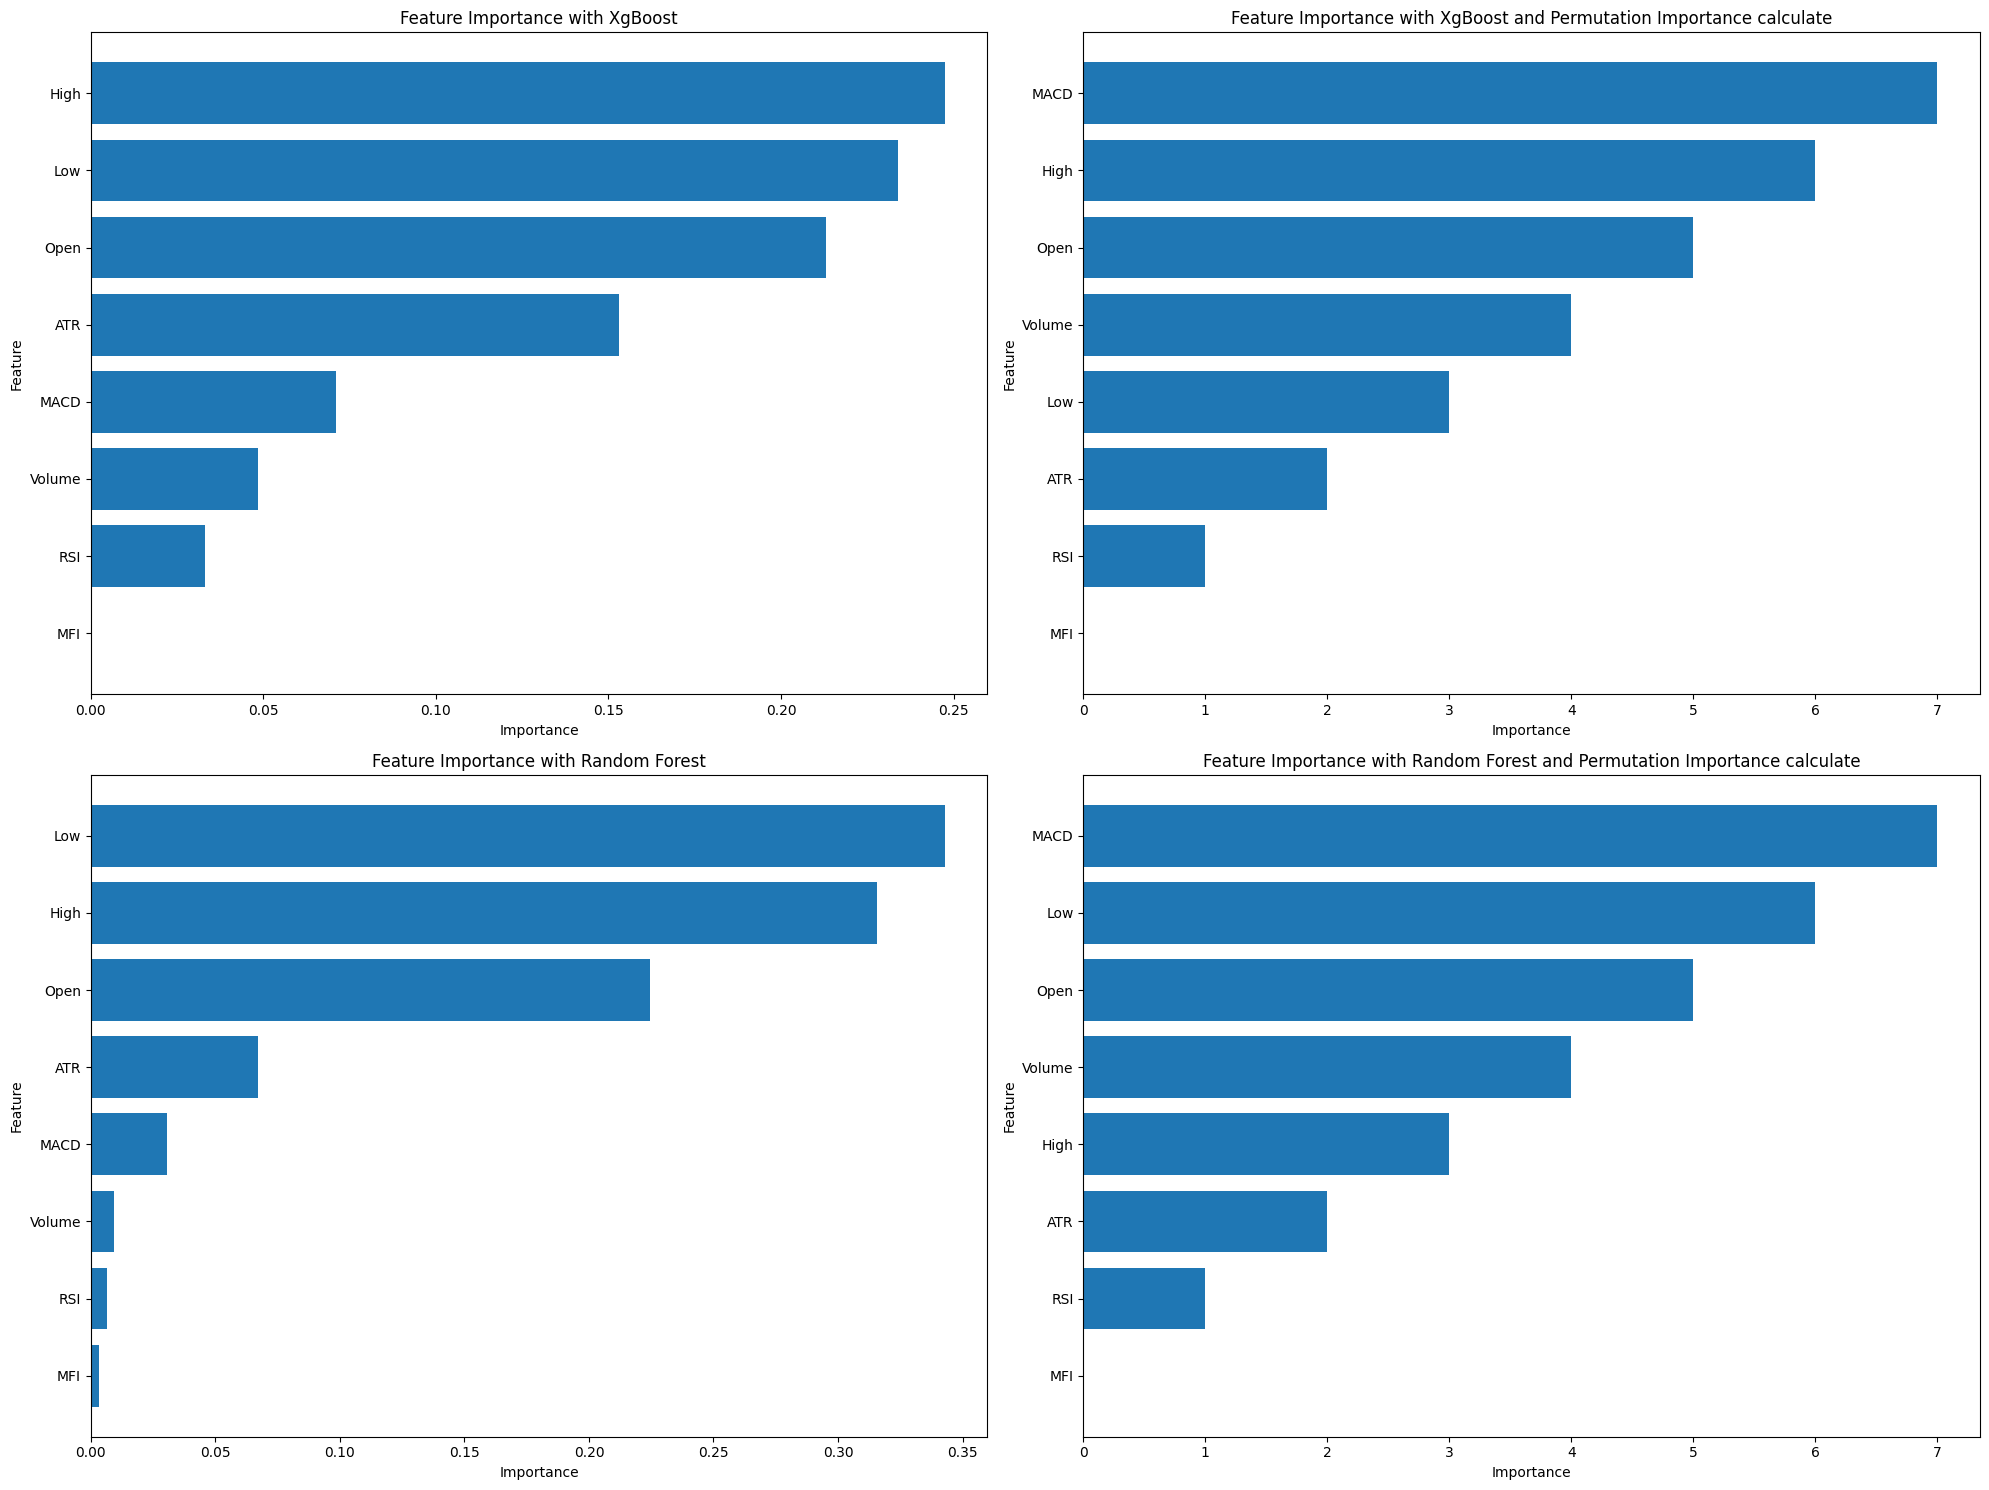

In [ ]:
import xgboost as xgb
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

columns = ['Close', 'Open', 'High', 'Low', 'Volume', 'MACD', 'MFI', 'RSI', 'ATR']
column = ['Open', 'High', 'Low', 'Volume', 'MACD', 'MFI', 'RSI', 'ATR']
data = data[columns]

train_size = int(len(data) * 0.9)

train = data[:train_size]
test = data['Close']
test = data[train_size:]
train = train[columns]
scaler = MinMaxScaler(feature_range = (0, 1))
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

X_train = train_scaled[:, 1:]
Y_train = train_scaled[:, 0].reshape(-1, 1)
X_train, Y_train = np.array(X_train), np.array(Y_train)

# Create the XGBoost model
model = xgb.XGBRegressor(n_estimator = 200, max_depth = 3, learning_rate = 0.01, subsample = 0.5, colsample_bytree = 0.5,
                         gamma = 0.2, reg_alpha = 0.1, reg_lambda = 0.1)
model.fit(X_train, Y_train)
importance_xgb = model.feature_importances_
feature_importances_xgb = pd.DataFrame({'Feature': column, 'Importance': importance_xgb})
feature_importances_xgb = feature_importances_xgb.sort_values(by='Importance', ascending=False)

# Tạo mô hình XGBoost và Feature Importan Calculte
model = xgb.XGBRegressor(n_estimator = 200, max_depth = 3, learning_rate = 0.01, subsample = 0.5, colsample_bytree = 0.5,
                         gamma = 0.2, reg_alpha = 0.1, reg_lambda = 0.1)
model.fit(X_train, Y_train)
result_pi = permutation_importance(model, X_train, Y_train)
importance_pi = result_pi.importances_mean.argsort()
feature_importances_pi = pd.DataFrame({'Feature': column, 'Importance': importance_pi})
feature_importances_pi = feature_importances_pi.sort_values(by='Importance', ascending=False)

#Create model with RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=6, min_samples_leaf=2,
                              max_features='sqrt', bootstrap=True, random_state=42)
model.fit(X_train, Y_train)
importance_rdf = model.feature_importances_

feature_importances_rdf = pd.DataFrame({'Feature': column, 'Importance': importance_rdf})
feature_importances_rdf = feature_importances_rdf.sort_values(by='Importance', ascending=False)

#Create model with RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=6, min_samples_leaf=2,
                              max_features='sqrt', bootstrap=True, random_state=42)
model.fit(X_train, Y_train)
result_rdfpi = permutation_importance(model, X_train, Y_train)
importance_rdfpi = result_rdfpi.importances_mean.argsort()
feature_importances_rdfpi = pd.DataFrame({'Feature': column, 'Importance': importance_rdfpi})
feature_importances_rdfpi = feature_importances_rdfpi.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(20, 15))

plt.subplot(2, 2, 1)
plt.barh(feature_importances_xgb['Feature'], feature_importances_xgb['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance with XgBoost')
plt.gca().invert_yaxis()

plt.subplot(2, 2, 2)
plt.barh(feature_importances_pi['Feature'], feature_importances_pi['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance with XgBoost and Permutation Importance calculate')
plt.gca().invert_yaxis()

plt.subplot(2, 2, 3)
plt.barh(feature_importances_rdf['Feature'], feature_importances_rdf['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance with Random Forest')
plt.gca().invert_yaxis()

plt.subplot(2, 2, 4)
plt.barh(feature_importances_rdfpi['Feature'], feature_importances_rdfpi['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance with Random Forest and Permutation Importance calculate')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()